In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:04<00:00, 39.1MB/s]


In [3]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()
net.to(device)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [5]:
num_epochs = 10

print("Starting training...")
for epoch in range(num_epochs):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 2000 == 1999:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

Starting training...
[1,  2000] loss: 2.232
[1,  4000] loss: 1.900
[1,  6000] loss: 1.688
[1,  8000] loss: 1.585
[1, 10000] loss: 1.530
[1, 12000] loss: 1.508
[2,  2000] loss: 1.427
[2,  4000] loss: 1.397
[2,  6000] loss: 1.380
[2,  8000] loss: 1.371
[2, 10000] loss: 1.341
[2, 12000] loss: 1.300
[3,  2000] loss: 1.227
[3,  4000] loss: 1.217
[3,  6000] loss: 1.220
[3,  8000] loss: 1.214
[3, 10000] loss: 1.193
[3, 12000] loss: 1.189
[4,  2000] loss: 1.086
[4,  4000] loss: 1.123
[4,  6000] loss: 1.107
[4,  8000] loss: 1.121
[4, 10000] loss: 1.107
[4, 12000] loss: 1.094
[5,  2000] loss: 1.011
[5,  4000] loss: 1.031
[5,  6000] loss: 1.046
[5,  8000] loss: 1.039
[5, 10000] loss: 1.057
[5, 12000] loss: 1.032
[6,  2000] loss: 0.969
[6,  4000] loss: 0.963
[6,  6000] loss: 0.998
[6,  8000] loss: 0.982
[6, 10000] loss: 0.976
[6, 12000] loss: 0.980
[7,  2000] loss: 0.891
[7,  4000] loss: 0.924
[7,  6000] loss: 0.903
[7,  8000] loss: 0.953
[7, 10000] loss: 0.953
[7, 12000] loss: 0.952
[8,  2000] lo

In [6]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy of the network on the 10000 test images: 63 %
Accuracy for class: plane is 71.3 %
Accuracy for class: car   is 87.3 %
Accuracy for class: bird  is 43.1 %
Accuracy for class: cat   is 41.8 %
Accuracy for class: deer  is 62.8 %
Accuracy for class: dog   is 57.3 %
Accuracy for class: frog  is 64.7 %
Accuracy for class: horse is 68.0 %
Accuracy for class: ship  is 70.1 %
Accuracy for class: truck is 66.6 %


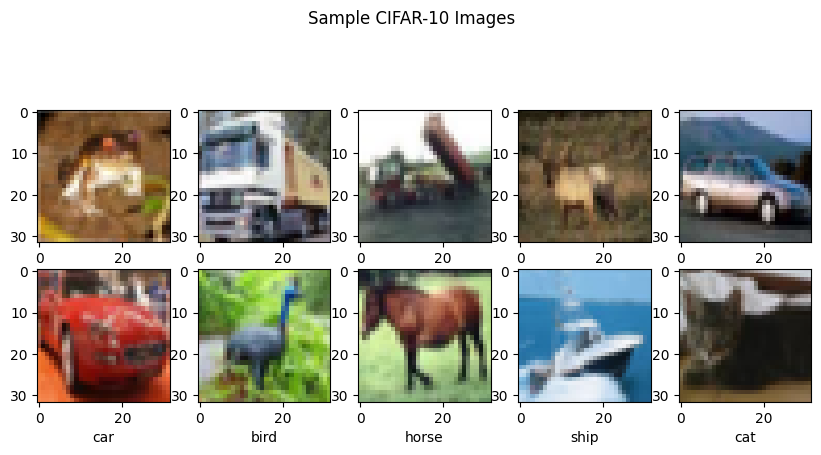

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.grid(False)
    plt.imshow(trainset.data[i])
    plt.xlabel(classes[trainset.targets[i]])
plt.suptitle("Sample CIFAR-10 Images")
plt.show()